In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i listings Airbnb
listings = pd.read_csv(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\listings.csv")

print(f"Listings caricati: {len(listings)}")
print(listings.columns.tolist())
listings.head()

Listings caricati: 10465
['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,28871,Comfortable double room,124245.0,1.462510e+18,Edwin,NaN,Centrum-West,52.367750,4.89092,Private room,94.0,1.0,799,2026-06-01,4.15,2.0,11,88,0363 607B EA74 0BD8 2F6F
1,29051,Comfortable single / double room,124245.0,1.462510e+18,Edwin,NaN,Centrum-Oost,52.365840,4.89111,Private room,NaN,1.0,906,2026-06-01,4.88,2.0,2,82,0363 607B EA74 0BD8 2F6F
2,44129,Luxury design with canal view,187728.0,1.462512e+18,Tanya,NaN,Centrum-West,52.382110,4.88630,Entire home/apt,314.0,3.0,186,2026-04-30,0.96,4.0,3,5,03635399E87602900F47
3,44391,Quiet 2-bedroom Amsterdam city centre apartment,194779.0,1.462512e+18,Jan,NaN,Centrum-Oost,52.371680,4.91471,Entire home/apt,NaN,3.0,42,2022-08-20,0.22,1.0,0,0,0363 E76E F06A C1DD 172C
4,48373,Cozy family home in Amsterdam South,220434.0,1.462513e+18,Vesna & Misha,NaN,Buitenveldert - Zuidas,52.327808,4.87680,Entire home/apt,NaN,3.0,5,2024-04-28,0.14,1.0,0,0,0363 4A2B A6AD 0196 F684


In [2]:
print("Tipi di alloggio:")
print(listings['room_type'].value_counts())

print("\nTop 10 quartieri per numero di listings:")
print(listings['neighbourhood'].value_counts().head(10))

print("\nPrezzo medio per tipo:")
print(listings.groupby('room_type')['price'].mean().round(1))

Tipi di alloggio:
room_type
Entire home/apt    8489
Private room       1929
Hotel room           26
Shared room          21
Name: count, dtype: int64

Top 10 quartieri per numero di listings:
neighbourhood
De Baarsjes - Oud-West                    1825
Centrum-West                              1217
De Pijp - Rivierenbuurt                   1201
Centrum-Oost                               933
Westerpark                                 720
Zuid                                       709
Oud-Oost                                   670
Bos en Lommer                              546
Oud-Noord                                  479
Oostelijk Havengebied - Indische Buurt     411
Name: count, dtype: int64

Prezzo medio per tipo:
room_type
Entire home/apt    394.6
Hotel room         249.8
Private room       203.7
Shared room         80.1
Name: price, dtype: float64


In [3]:
# Convertiamo listings in GeoDataFrame
listings_geo = gpd.GeoDataFrame(
    listings,
    geometry=gpd.points_from_xy(listings['longitude'], listings['latitude']),
    crs="EPSG:4326"
)

# Carichiamo i quartieri Airbnb
neighbourhoods = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\neighbourhoods.geojson")

print(f"Quartieri Airbnb: {len(neighbourhoods)}")
print(neighbourhoods.columns.tolist())
print(neighbourhoods['neighbourhood'].head(10))

Quartieri Airbnb: 22
['neighbourhood', 'neighbourhood_group', 'geometry']
0                              Bijlmer-Oost
1                                 Oud-Noord
2                                Noord-Oost
3                                Noord-West
4                  IJburg - Zeeburgereiland
5                              Centrum-West
6    Oostelijk Havengebied - Indische Buurt
7                              Centrum-Oost
8                                  Oud-Oost
9                                Westerpark
Name: neighbourhood, dtype: object


In [4]:
# Contiamo listings per quartiere
listings_per_quartiere = listings.groupby('neighbourhood').size().reset_index()
listings_per_quartiere.columns = ['neighbourhood', 'num_listings']

# Uniamo con le geometrie
neighbourhoods_data = neighbourhoods.merge(listings_per_quartiere, on='neighbourhood', how='left')
neighbourhoods_data = neighbourhoods_data.to_crs("EPSG:28992")

print(neighbourhoods_data[['neighbourhood', 'num_listings']].sort_values('num_listings', ascending=False))

                             neighbourhood  num_listings
16                  De Baarsjes - Oud-West          1825
5                             Centrum-West          1217
13                 De Pijp - Rivierenbuurt          1201
7                             Centrum-Oost           933
9                               Westerpark           720
14                                    Zuid           709
8                                 Oud-Oost           670
17                           Bos en Lommer           546
1                                Oud-Noord           479
6   Oostelijk Havengebied - Indische Buurt           411
3                               Noord-West           312
10                         Watergraafsmeer           304
19                             Slotervaart           223
4                 IJburg - Zeeburgereiland           187
2                               Noord-Oost           179
18                 Geuzenveld - Slotermeer           141
15                  Buitenvelde

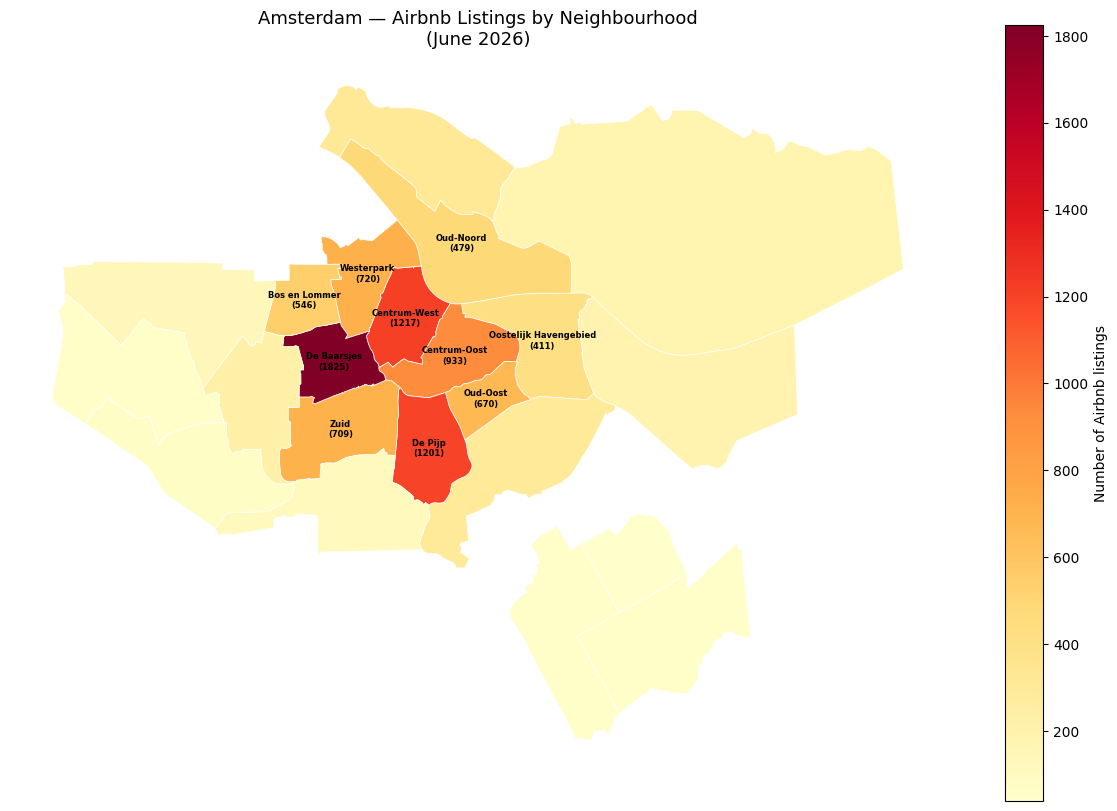

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

neighbourhoods_data.plot(
    column='num_listings',
    cmap='YlOrRd',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Number of Airbnb listings', 'shrink': 0.8},
    edgecolor='white',
    linewidth=0.5
)

# Aggiungiamo etichette per i quartieri più grandi
for _, row in neighbourhoods_data[neighbourhoods_data['num_listings'] > 400].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['neighbourhood'].split(' - ')[0]}\n({row['num_listings']})",
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=6, fontweight='bold',
        color='black'
    )

ax.set_title('Amsterdam — Airbnb Listings by Neighbourhood\n(June 2026)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_airbnb_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Carichiamo i buurt con popolazione
buurten = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten_proj = buurten.to_crs("EPSG:28992")

# Carichiamo la popolazione CBS
obs = pd.read_csv(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\Observations.csv", sep=';')
codes = pd.read_csv(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\WijkenEnBuurtenCodes.csv", sep=';')

obs.columns = [c.replace('ï»¿', '') for c in obs.columns]
amsterdam_buurten = codes[codes['Identifier'].str.startswith('BU0363', na=False)]
pop_data = obs[
    (obs['WijkenEnBuurten'].isin(amsterdam_buurten['Identifier'])) &
    (obs['Measure'] == 'T001036') &
    (obs['Value'].notna())
].copy()

pop_named = pop_data.merge(
    amsterdam_buurten[['Identifier', 'Title']],
    left_on='WijkenEnBuurten', right_on='Identifier', how='left'
)
pop_named['Value'] = pd.to_numeric(pop_named['Value'], errors='coerce')

# Uniamo popolazione con buurten
buurten_pop = buurten_proj.merge(
    pop_named[['Identifier', 'Value']],
    left_on='CBS_Buurtcode', right_on='Identifier', how='left'
)
buurten_pop.columns = [*buurten_pop.columns[:-1], 'Popolazione']

# Join spaziale: buurt → quartiere Airbnb
neighbourhoods_proj = neighbourhoods_data.to_crs("EPSG:28992")
joined = gpd.sjoin(buurten_pop[['CBS_Buurtcode', 'Popolazione', 'geometry']], 
                   neighbourhoods_proj[['neighbourhood', 'num_listings', 'geometry']],
                   how='left', predicate='intersects')

# Aggreghiamo per quartiere Airbnb
pop_per_quartiere = joined.groupby('neighbourhood').agg(
    Popolazione=('Popolazione', 'sum'),
    Listings=('num_listings', 'first')
).reset_index()

pop_per_quartiere['Airbnb_per_1000'] = (
    pop_per_quartiere['Listings'] / pop_per_quartiere['Popolazione'] * 1000
).round(1)

print(pop_per_quartiere[['neighbourhood', 'Popolazione', 'Listings', 'Airbnb_per_1000']]
      .sort_values('Airbnb_per_1000', ascending=False))

                             neighbourhood  Popolazione  Listings  \
7                   De Baarsjes - Oud-West      98055.0    1825.0   
5                             Centrum-West      71905.0    1217.0   
8                  De Pijp - Rivierenbuurt      77750.0    1201.0   
20                              Westerpark      60610.0     720.0   
4                             Centrum-Oost      82945.0     933.0   
21                                    Zuid      67800.0     709.0   
17                                Oud-Oost      75300.0     670.0   
2                            Bos en Lommer      65740.0     546.0   
16                               Oud-Noord      68950.0     479.0   
13                              Noord-West      50570.0     312.0   
14  Oostelijk Havengebied - Indische Buurt      67235.0     411.0   
11                IJburg - Zeeburgereiland      36990.0     187.0   
19                         Watergraafsmeer      68935.0     304.0   
3                   Buitenveldert 

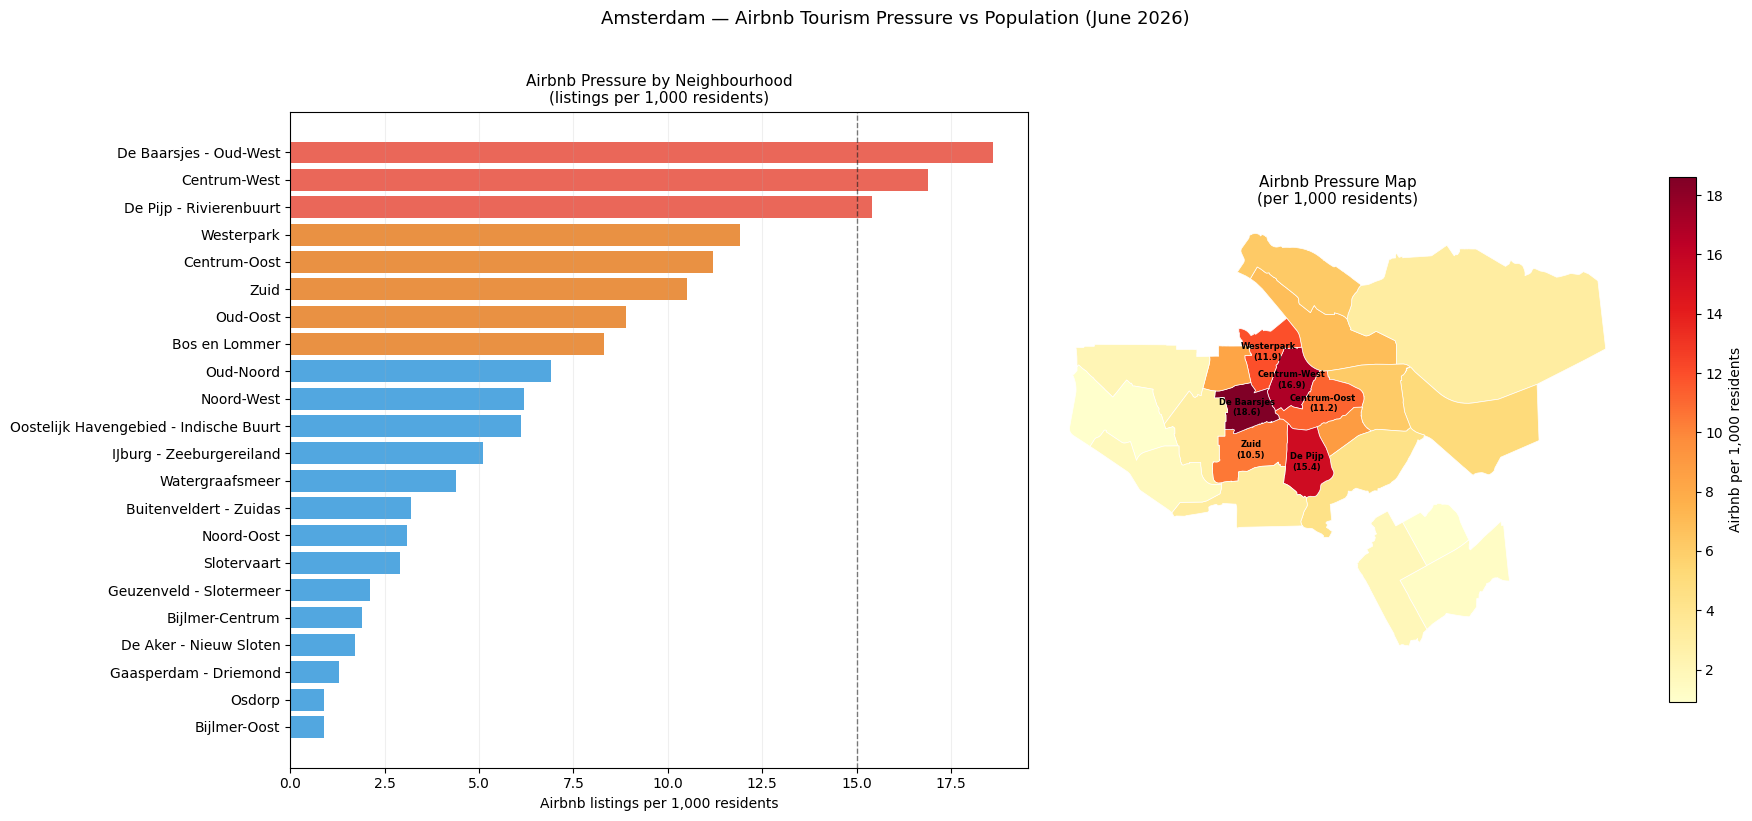

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Grafico a barre
pop_plot = pop_per_quartiere.sort_values('Airbnb_per_1000', ascending=True)
colori = ['#e74c3c' if v > 15 else '#e67e22' if v > 8 else '#3498db' 
          for v in pop_plot['Airbnb_per_1000']]

ax1.barh(pop_plot['neighbourhood'], pop_plot['Airbnb_per_1000'],
         color=colori, alpha=0.85)
ax1.axvline(x=15, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Airbnb listings per 1,000 residents')
ax1.set_title('Airbnb Pressure by Neighbourhood\n(listings per 1,000 residents)', fontsize=11)
ax1.grid(True, alpha=0.2, axis='x')

# Mappa
neighbourhoods_final = neighbourhoods_proj.merge(
    pop_per_quartiere[['neighbourhood', 'Airbnb_per_1000']], 
    on='neighbourhood', how='left'
)

neighbourhoods_final.plot(
    column='Airbnb_per_1000',
    cmap='YlOrRd',
    ax=ax2,
    legend=True,
    legend_kwds={'label': 'Airbnb per 1,000 residents', 'shrink': 0.8},
    edgecolor='white',
    linewidth=0.5
)

for _, row in neighbourhoods_final[neighbourhoods_final['Airbnb_per_1000'] > 10].iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(
        f"{row['neighbourhood'].split(' - ')[0]}\n({row['Airbnb_per_1000']})",
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=6, fontweight='bold'
    )

ax2.set_title('Airbnb Pressure Map\n(per 1,000 residents)', fontsize=11)
ax2.set_axis_off()

plt.suptitle('Amsterdam — Airbnb Tourism Pressure vs Population (June 2026)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_airbnb_pressure.png', dpi=150, bbox_inches='tight')
plt.show()